# Demand Forecasting - Feature Engineering, Modeling and Evaluation

This notebook covers the full pipeline:
- Feature engineering (lag, rolling, calendar, competition, store metadata)
- Leakage prevention verification
- Model training (Naive baseline, SARIMA, LightGBM, XGBoost)
- Walk-forward evaluation
- Store-level analysis and business recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

warnings.filterwarnings('ignore')

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## 1. Load and Prepare Base Data

In [2]:
train = pd.read_csv('/kaggle/input/datasets/nehamalik10/demand-forecasting-dataset/train.csv', parse_dates=['Date'], low_memory=False)
store = pd.read_csv('/kaggle/input/datasets/nehamalik10/demand-forecasting-dataset/store.csv')

df = train.merge(store, on='Store', how='left')
df = df.sort_values(['Store', 'Date']).reset_index(drop=True)

# Remove closed-store days (Sales=0 is operational, not demand)
df = df[df['Open'] == 1].copy()

# Handle missing values
max_dist = df['CompetitionDistance'].max()
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(max_dist * 2)
df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].fillna(0).astype(int)
df['CompetitionOpenSinceYear'] = df['CompetitionOpenSinceYear'].fillna(0).astype(int)
df['Promo2SinceWeek'] = df['Promo2SinceWeek'].fillna(0).astype(int)
df['Promo2SinceYear'] = df['Promo2SinceYear'].fillna(0).astype(int)
df['PromoInterval'] = df['PromoInterval'].fillna('')

# Calendar features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['IsWeekend'] = (df['Date'].dt.dayofweek >= 5).astype(int)
df['IsMonthStart'] = df['Date'].dt.is_month_start.astype(int)
df['IsMonthEnd'] = df['Date'].dt.is_month_end.astype(int)

# Encode store-level categoricals (these MUST be numeric for tree models)
df['StoreType_encoded'] = df['StoreType'].map({'a': 1, 'b': 2, 'c': 3, 'd': 4})
df['Assortment_encoded'] = df['Assortment'].map({'a': 1, 'b': 2, 'c': 3})
holiday_map = {'0': 0, 0: 0, 'a': 1, 'b': 2, 'c': 3}
df['StateHoliday_encoded'] = df['StateHoliday'].map(holiday_map).fillna(0).astype(int)

# Verify encodings exist
print(f'Dataset: {len(df):,} rows, Date: {df["Date"].min().date()} to {df["Date"].max().date()}')
print(f'StoreType_encoded unique: {sorted(df["StoreType_encoded"].unique())}')
print(f'Assortment_encoded unique: {sorted(df["Assortment_encoded"].unique())}')
print(f'StateHoliday_encoded unique: {sorted(df["StateHoliday_encoded"].unique())}')

Dataset: 844,392 rows, Date: 2013-01-01 to 2015-07-31
StoreType_encoded unique: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Assortment_encoded unique: [np.int64(1), np.int64(2), np.int64(3)]
StateHoliday_encoded unique: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


## 2. Lag Features

In [3]:
for lag in [1, 7, 14, 28]:
    df[f'Sales_lag_{lag}'] = df.groupby('Store')['Sales'].shift(lag)

sample = df[df['Store'] == 1][['Date', 'Sales', 'Sales_lag_1', 'Sales_lag_7']].dropna().head(5)
print('Verification (Store 1):')
sample

Verification (Store 1):


,Date,Sales,Sales_lag_1,Sales_lag_7
9,2013-01-10,4892,5471.0,5530.0
10,2013-01-11,4881,4892.0,4327.0
11,2013-01-12,4952,4881.0,4486.0
13,2013-01-14,4717,4952.0,4997.0
14,2013-01-15,3900,4717.0,7176.0


## 3. Rolling Window Features

`shift(1)` before rolling ensures the current day's sales are NOT included.

In [4]:
for window in [7, 28]:
    shifted = df.groupby('Store')['Sales'].shift(1)
    df[f'Sales_rolling_mean_{window}'] = shifted.groupby(df['Store']).transform(
        lambda x: x.rolling(window, min_periods=1).mean()
    )
    df[f'Sales_rolling_std_{window}'] = shifted.groupby(df['Store']).transform(
        lambda x: x.rolling(window, min_periods=1).std()
    )

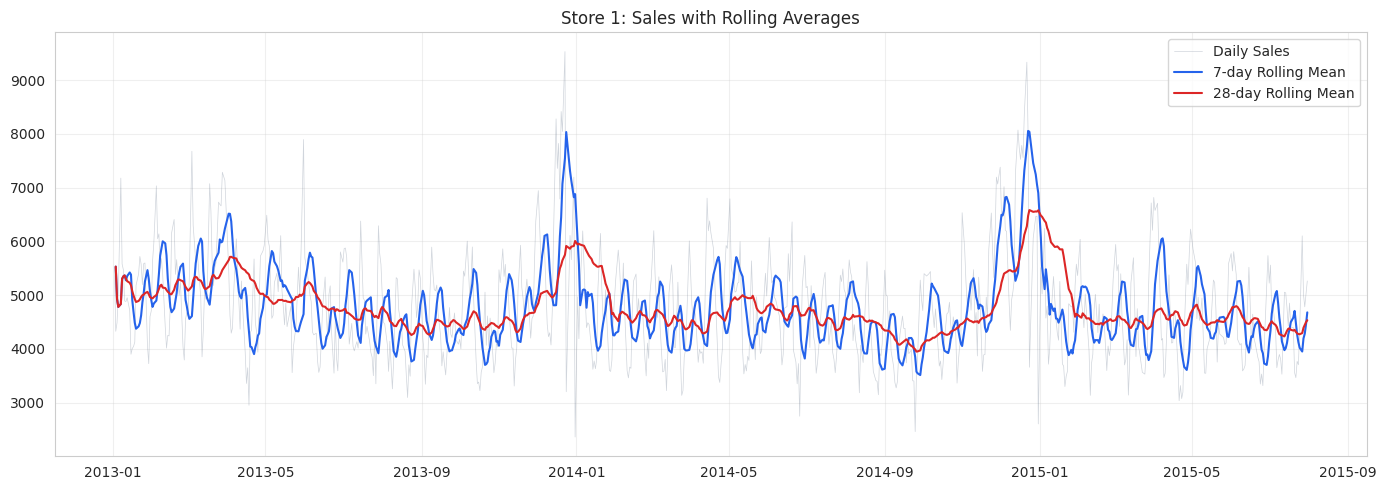

In [5]:
store_1 = df[df['Store'] == 1].copy()
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(store_1['Date'], store_1['Sales'], color='#64748b', alpha=0.3, lw=0.5, label='Daily Sales')
ax.plot(store_1['Date'], store_1['Sales_rolling_mean_7'], color='#2563eb', lw=1.5, label='7-day Rolling Mean')
ax.plot(store_1['Date'], store_1['Sales_rolling_mean_28'], color='#dc2626', lw=1.5, label='28-day Rolling Mean')
ax.set_title('Store 1: Sales with Rolling Averages')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Holiday Proximity and Competition Features

In [6]:
is_holiday = (df['StateHoliday'] != '0') & (df['StateHoliday'] != 0)
holiday_dates = pd.to_datetime(sorted(df.loc[is_holiday, 'Date'].unique()))

def compute_holiday_proximity(date):
    diffs = (holiday_dates - date).days
    future = diffs[diffs > 0]
    past = diffs[diffs <= 0]
    return (int(future.min()) if len(future) > 0 else 999,
            int(abs(past.max())) if len(past) > 0 else 999)

proximity_map = {d: compute_holiday_proximity(d) for d in df['Date'].unique()}
df['days_to_holiday'] = df['Date'].map(lambda x: proximity_map[x][0])
df['days_since_holiday'] = df['Date'].map(lambda x: proximity_map[x][1])

# Competition open duration in months
df['CompetitionOpen'] = 0
mask = (df['CompetitionOpenSinceYear'] > 0) & (df['CompetitionOpenSinceMonth'] > 0)
df.loc[mask, 'CompetitionOpen'] = (
    (df.loc[mask, 'Date'].dt.year - df.loc[mask, 'CompetitionOpenSinceYear']) * 12
    + (df.loc[mask, 'Date'].dt.month - df.loc[mask, 'CompetitionOpenSinceMonth'])
)
df['CompetitionOpen'] = df['CompetitionOpen'].clip(lower=0)

print('Holiday and competition features added.')

Holiday and competition features added.


## 5. Drop Rows with Insufficient History

In [7]:
lag_cols = [col for col in df.columns if 'lag_' in col or 'rolling_' in col]
initial_len = len(df)
df = df.dropna(subset=lag_cols).copy()
print(f'Dropped {initial_len - len(df):,} rows with insufficient history. Remaining: {len(df):,}')

Dropped 31,220 rows with insufficient history. Remaining: 813,172


## 6. Feature Set and Correlation

All 26 features present.


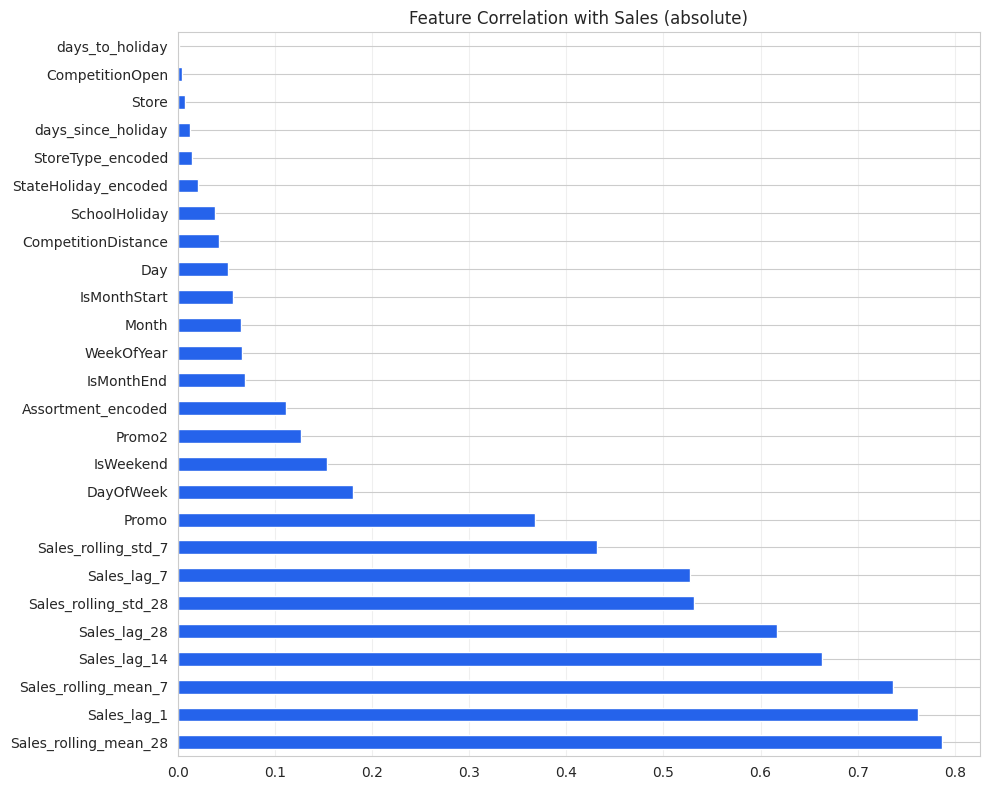

In [8]:
feature_cols = [
    'DayOfWeek', 'Month', 'Day', 'WeekOfYear',
    'IsWeekend', 'IsMonthStart', 'IsMonthEnd',
    'Store', 'StoreType_encoded', 'Assortment_encoded',
    'CompetitionDistance', 'CompetitionOpen',
    'Promo', 'Promo2',
    'SchoolHoliday', 'StateHoliday_encoded',
    'days_to_holiday', 'days_since_holiday',
    'Sales_lag_1', 'Sales_lag_7', 'Sales_lag_14', 'Sales_lag_28',
    'Sales_rolling_mean_7', 'Sales_rolling_std_7',
    'Sales_rolling_mean_28', 'Sales_rolling_std_28',
]

# Verify all features exist
missing = [col for col in feature_cols if col not in df.columns]
if missing:
    print(f'WARNING: Missing features: {missing}')
else:
    print(f'All {len(feature_cols)} features present.')

correlations = df[feature_cols + ['Sales']].corr()['Sales'].drop('Sales').abs().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 8))
correlations.plot(kind='barh', ax=ax, color='#2563eb', edgecolor='white')
ax.set_title('Feature Correlation with Sales (absolute)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

---
## 7. Time-Based Train/Test Split

Final 6 weeks held out, evaluated once. Random splits would leak future data into training.

In [9]:
cutoff = df['Date'].max() - pd.Timedelta(weeks=6)
train_df = df[df['Date'] <= cutoff].copy()
test_df = df[df['Date'] > cutoff].copy()

X_train, y_train = train_df[feature_cols], train_df['Sales']
X_test, y_test = test_df[feature_cols], test_df['Sales']

print(f'Train: {len(X_train):,} | Test: {len(X_test):,} | Features: {len(feature_cols)}')

Train: 772,890 | Test: 40,282 | Features: 26


In [10]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def rmspe(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2)) * 100

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.array(y_true) - np.array(y_pred)) ** 2))

def evaluate_forecast(y_true, y_pred, model_name):
    metrics = {
        'model': model_name,
        'MAPE (%)': round(mape(y_true, y_pred), 2),
        'RMSE': round(rmse(y_true, y_pred), 2),
        'RMSPE (%)': round(rmspe(y_true, y_pred), 2),
    }
    print(f'\n{"="*55}')
    print(f'  {model_name}')
    print(f'{"="*55}')
    print(f'  MAPE:  {metrics["MAPE (%)"]:.2f}%  |  RMSE: {metrics["RMSE"]:.2f}  |  RMSPE: {metrics["RMSPE (%)"]:.2f}%')
    return metrics

## 8. Naive Baseline

In [11]:
test_with_naive = test_df.copy()
naive_preds = df.groupby('Store')['Sales'].shift(7)
test_with_naive['naive_pred'] = naive_preds.loc[test_df.index]
naive_valid = test_with_naive.dropna(subset=['naive_pred'])

all_results = []
all_results.append(evaluate_forecast(naive_valid['Sales'], naive_valid['naive_pred'], 'Naive (Same-Day-Last-Week)'))


  Naive (Same-Day-Last-Week)
  MAPE:  37.64%  |  RMSE: 3063.00  |  RMSPE: 48.95%


## 9. SARIMA (Statistical Baseline)

**Note on comparability**: SARIMA is fit on daily sales *averaged across all stores* (a single, smoother series), while the ML models predict at the individual store-day level. This makes the SARIMA task inherently easier. The comparison is included to show the value of statistical baselines, but the numbers are not directly comparable to the store-level ML metrics.

Fitting SARIMA on aggregate daily sales (not store-level)...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



  SARIMA (aggregate-level*)
  MAPE:  12.87%  |  RMSE: 1101.51  |  RMSPE: 16.34%


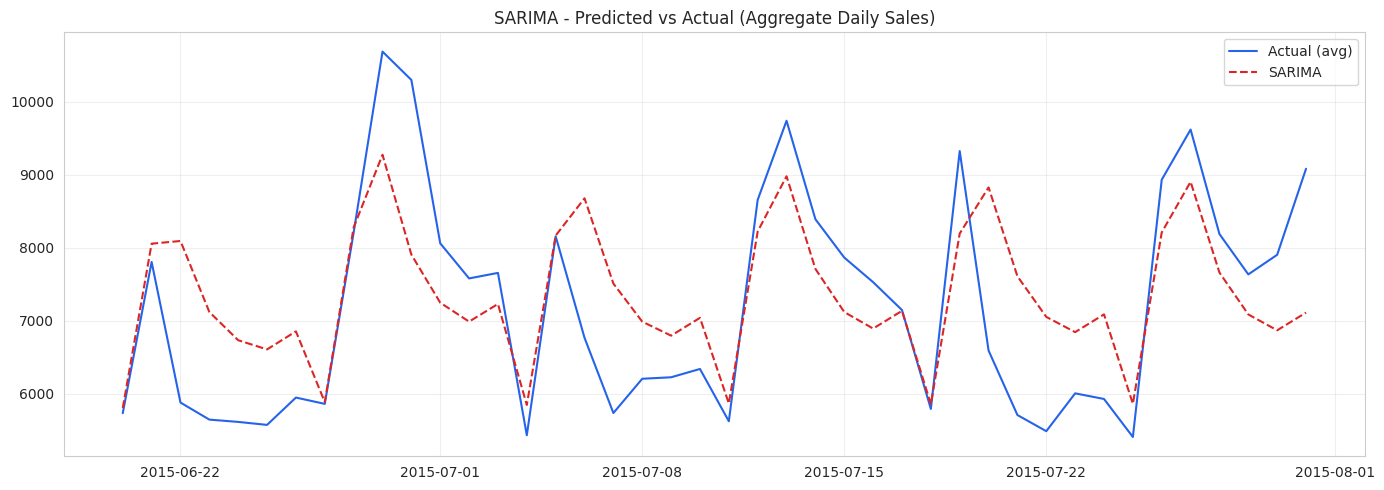

* SARIMA metrics are on aggregate daily avg, not store-level. Not directly comparable to ML models.


In [12]:
daily_train = train_df.groupby('Date')['Sales'].mean().sort_index()
daily_test = test_df.groupby('Date')['Sales'].mean().sort_index()

print('Fitting SARIMA on aggregate daily sales (not store-level)...')
sarima = SARIMAX(daily_train, order=(1,1,1), seasonal_order=(1,1,1,7),
                 enforce_stationarity=False, enforce_invertibility=False)
sarima_result = sarima.fit(disp=False)
sarima_forecast = sarima_result.forecast(steps=len(daily_test))

sarima_eval = evaluate_forecast(daily_test.values, sarima_forecast.values, 'SARIMA (aggregate-level*)')
all_results.append(sarima_eval)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_test.index, daily_test.values, color='#2563eb', lw=1.5, label='Actual (avg)')
ax.plot(daily_test.index, sarima_forecast.values, color='#dc2626', lw=1.5, linestyle='--', label='SARIMA')
ax.set_title('SARIMA - Predicted vs Actual (Aggregate Daily Sales)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('* SARIMA metrics are on aggregate daily avg, not store-level. Not directly comparable to ML models.')

## 10. LightGBM

In [13]:
lgbm_model = LGBMRegressor(
    n_estimators=500, max_depth=7, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_samples=20,
    random_state=42, verbose=-1, n_jobs=-1
)
lgbm_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], callbacks=[])
lgbm_pred = np.clip(lgbm_model.predict(X_test), 0, None)
all_results.append(evaluate_forecast(y_test, lgbm_pred, 'LightGBM (store-level)'))


  LightGBM (store-level)
  MAPE:  10.82%  |  RMSE: 961.44  |  RMSPE: 15.15%


## 11. XGBoost

In [14]:
xgb_model = XGBRegressor(
    n_estimators=500, max_depth=7, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    random_state=42, n_jobs=-1
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
xgb_pred = np.clip(xgb_model.predict(X_test), 0, None)
all_results.append(evaluate_forecast(y_test, xgb_pred, 'XGBoost (store-level)'))


  XGBoost (store-level)
  MAPE:  10.73%  |  RMSE: 959.33  |  RMSPE: 14.79%


## 12. Model Comparison

SARIMA is marked with an asterisk because it operates at aggregate level, not store-day level.

In [15]:
comparison = pd.DataFrame(all_results).sort_values('MAPE (%)', ascending=True).reset_index(drop=True)
print('Model Comparison:\n')
comparison

Model Comparison:



,model,MAPE (%),RMSE,RMSPE (%)
0,XGBoost (store-level),10.73,959.33,14.79
1,LightGBM (store-level),10.82,961.44,15.15
2,SARIMA (aggregate-level*),12.87,1101.51,16.34
3,Naive (Same-Day-Last-Week),37.64,3063.00,48.95


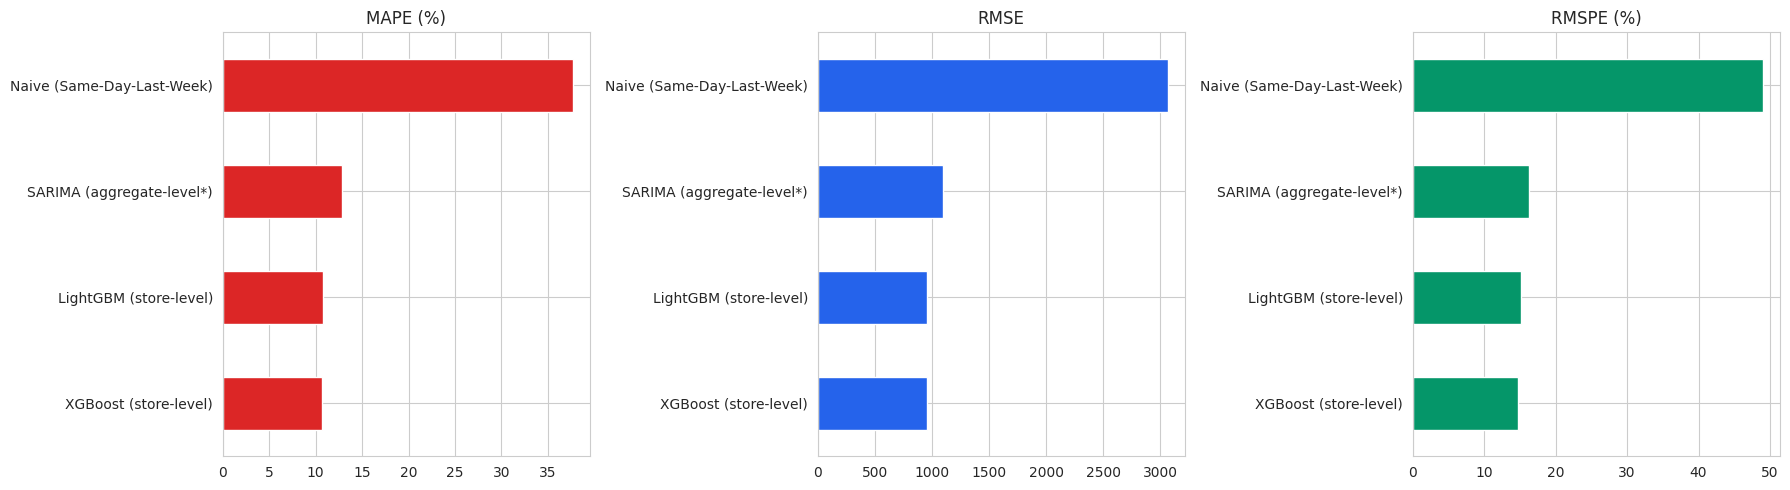

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, color in zip(axes, ['MAPE (%)', 'RMSE', 'RMSPE (%)'], ['#dc2626', '#2563eb', '#059669']):
    comparison.plot(x='model', y=metric, kind='barh', ax=ax, color=color, edgecolor='white', legend=False)
    ax.set_title(metric)
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 13. Best Model Analysis

Best store-level model: XGBoost (store-level)


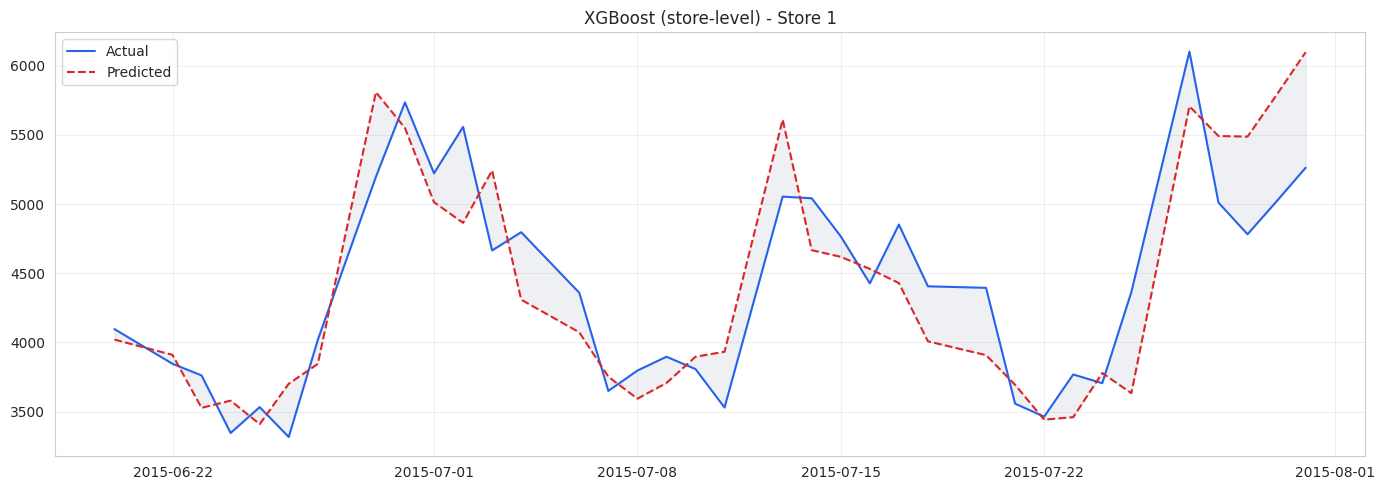

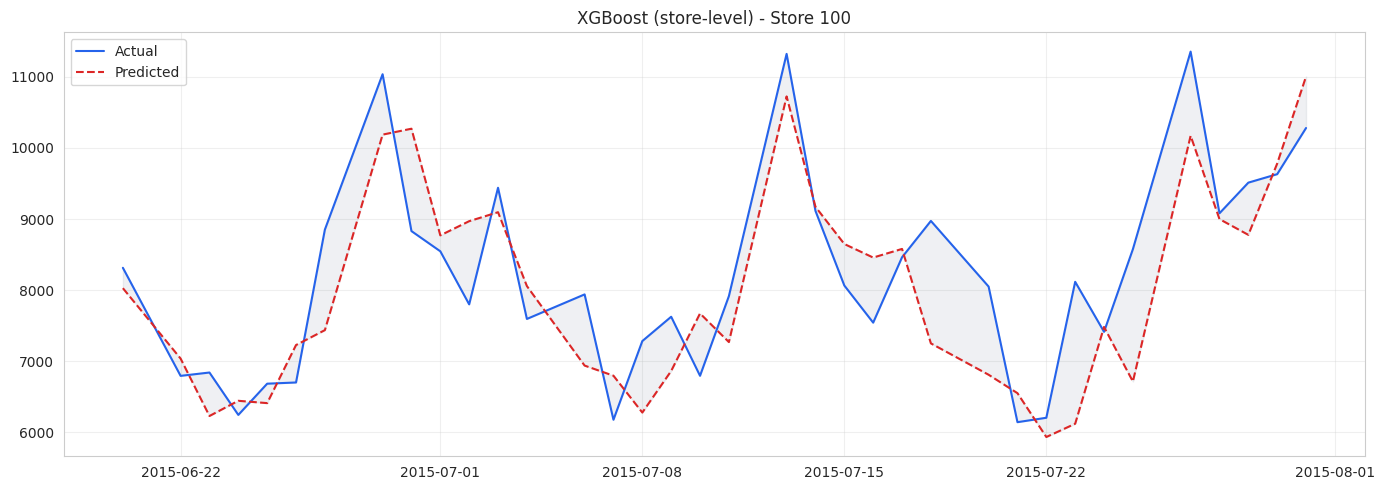

In [17]:
# Select best among store-level models only
store_level = comparison[~comparison['model'].str.contains('SARIMA')]
best_name = store_level.iloc[0]['model']
best_pred = lgbm_pred if 'LightGBM' in best_name else xgb_pred
best_model = lgbm_model if 'LightGBM' in best_name else xgb_model
print(f'Best store-level model: {best_name}')

# Save model
joblib.dump(best_model, '/kaggle/working/forecasting_model.pkl')

for store_id in [1, 100]:
    mask = test_df['Store'] == store_id
    if mask.sum() > 0:
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.plot(test_df.loc[mask, 'Date'], y_test[mask], color='#2563eb', lw=1.5, label='Actual')
        ax.plot(test_df.loc[mask, 'Date'], best_pred[mask], color='#dc2626', lw=1.5, linestyle='--', label='Predicted')
        ax.fill_between(test_df.loc[mask, 'Date'], y_test[mask], best_pred[mask], alpha=0.1, color='#64748b')
        ax.set_title(f'{best_name} - Store {store_id}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

In [22]:
import joblib
joblib.dump(best_model, '/kaggle/working/forecasting_model.pkl')

['/kaggle/working/forecasting_model.pkl']

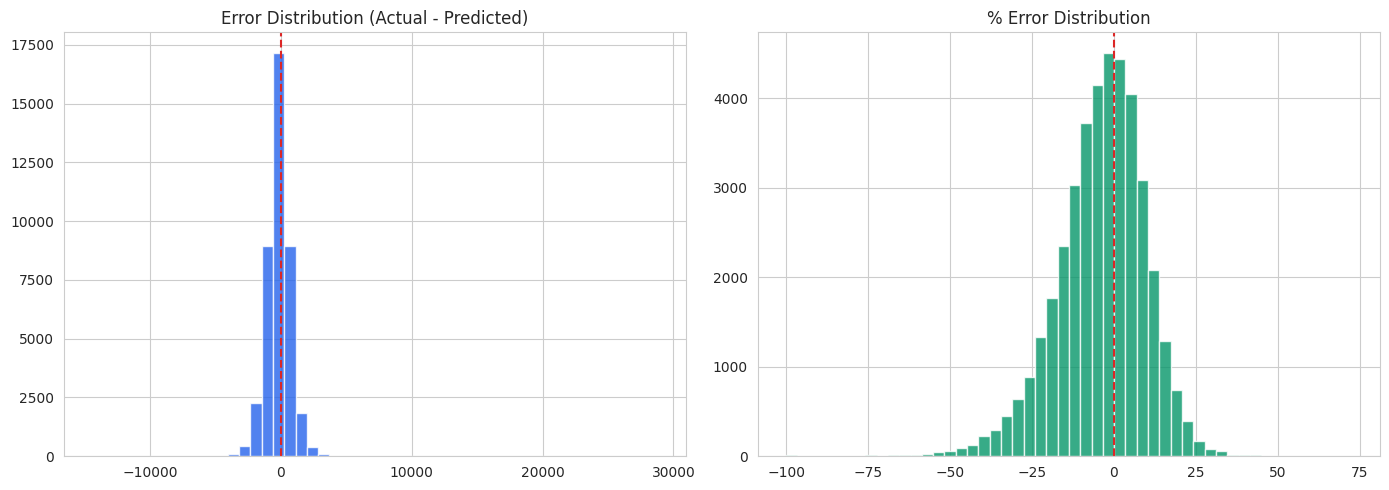

In [18]:
# Error distribution
errors = np.array(y_test) - best_pred
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(errors, bins=50, color='#2563eb', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0, color='#dc2626', linestyle='--', lw=1.5)
axes[0].set_title('Error Distribution (Actual - Predicted)')
pct_errors = np.clip(errors / np.where(y_test != 0, y_test, 1) * 100, -100, 100)
axes[1].hist(pct_errors, bins=50, color='#059669', edgecolor='white', alpha=0.8)
axes[1].axvline(x=0, color='#dc2626', linestyle='--', lw=1.5)
axes[1].set_title('% Error Distribution')
plt.tight_layout()
plt.show()

## 14. Feature Importance

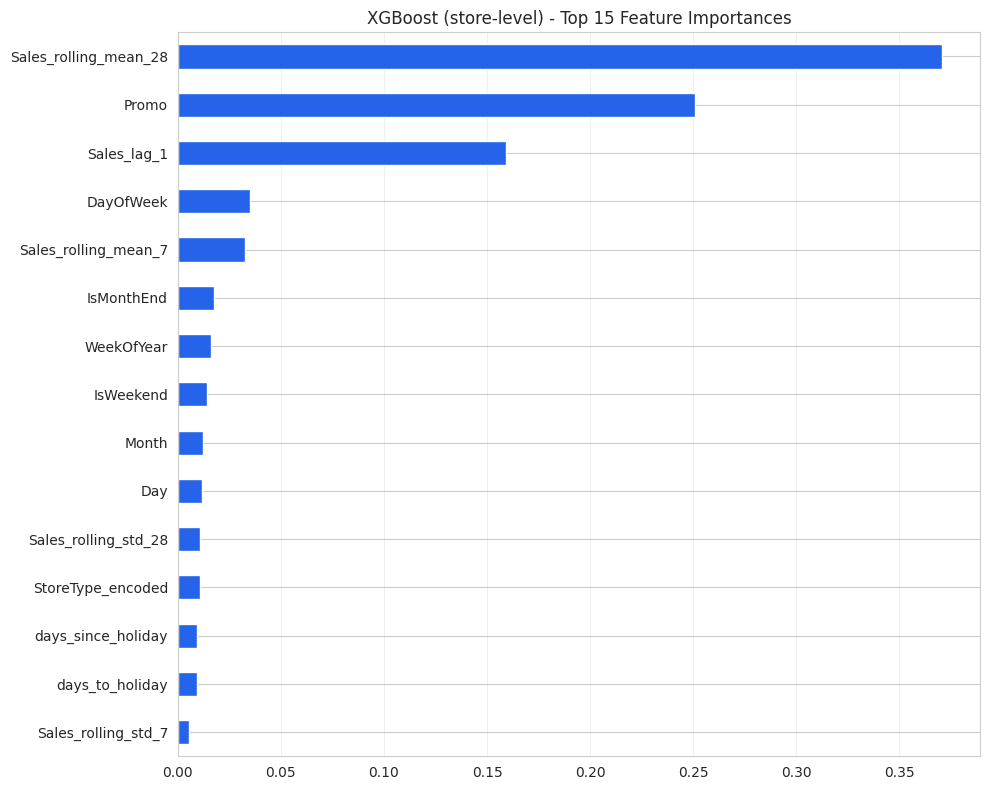

In [19]:
importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 8))
importances.tail(15).plot(kind='barh', ax=ax, color='#2563eb', edgecolor='white')
ax.set_title(f'{best_name} - Top 15 Feature Importances')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 15. Store-Level Forecast Difficulty

Store-level MAPE: Median=10.22%, Mean=10.79%
Best: 4.99% (Store 262) | Worst: 81.63% (Store 292)


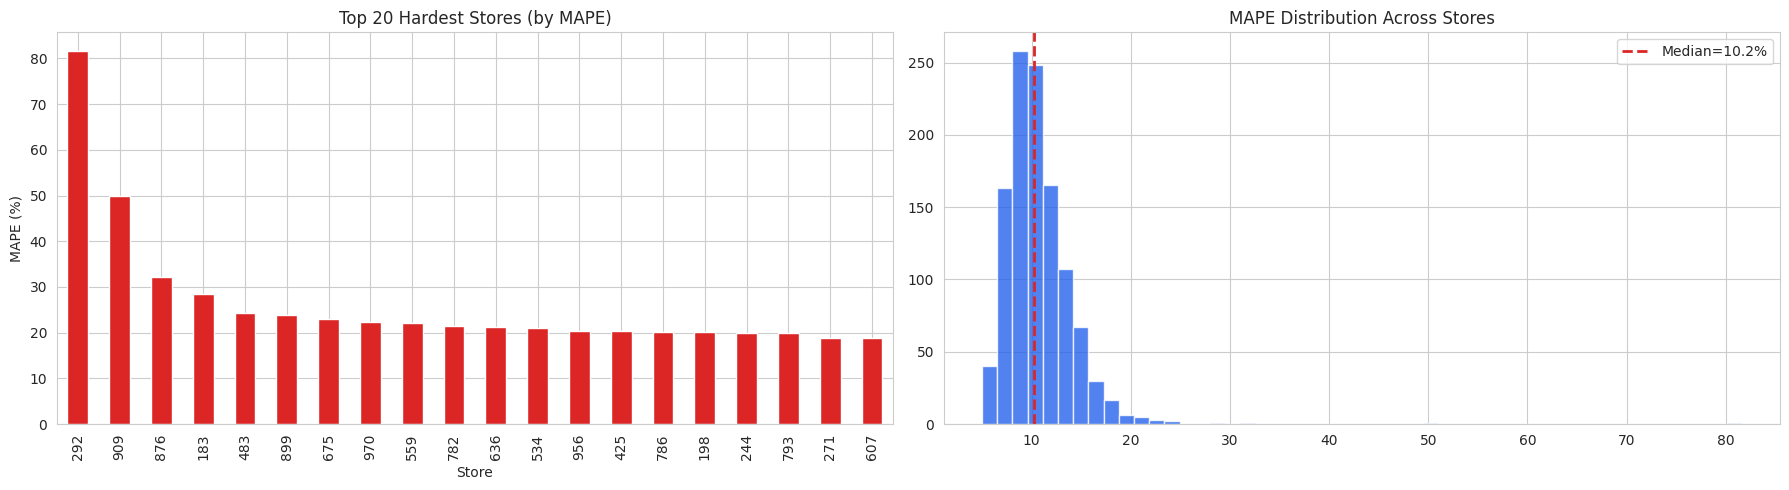

In [20]:
test_results = test_df[['Store', 'Sales']].copy()
test_results['Predicted'] = best_pred
store_mape = test_results.groupby('Store').apply(lambda g: mape(g['Sales'], g['Predicted']))

print(f'Store-level MAPE: Median={store_mape.median():.2f}%, Mean={store_mape.mean():.2f}%')
print(f'Best: {store_mape.min():.2f}% (Store {store_mape.idxmin()}) | Worst: {store_mape.max():.2f}% (Store {store_mape.idxmax()})')

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
store_mape.nlargest(20).plot(kind='bar', ax=axes[0], color='#dc2626', edgecolor='white')
axes[0].set_title('Top 20 Hardest Stores (by MAPE)')
axes[0].set_ylabel('MAPE (%)')
axes[1].hist(store_mape, bins=50, color='#2563eb', edgecolor='white', alpha=0.8)
axes[1].axvline(x=store_mape.median(), color='#dc2626', linestyle='--', lw=2, label=f'Median={store_mape.median():.1f}%')
axes[1].set_title('MAPE Distribution Across Stores')
axes[1].legend()
plt.tight_layout()
plt.show()

## 16. Business Translation

In [21]:
test_full = test_df.copy()
test_full['Predicted'] = best_pred

if 'Promo' in test_full.columns:
    promo_pred = test_full.groupby('Promo')['Predicted'].mean()
    print('Predicted demand by promo:')
    print(f'  No promo: {promo_pred.get(0, 0):.0f} | With promo: {promo_pred.get(1, 0):.0f}')
    if 0 in promo_pred.index and 1 in promo_pred.index:
        print(f'  Lift: +{(promo_pred[1] / promo_pred[0] - 1) * 100:.1f}%')

if 'DayOfWeek' in test_full.columns:
    dow_pred = test_full.groupby('DayOfWeek')['Predicted'].mean()
    day_names = {1:'Mon', 2:'Tue', 3:'Wed', 4:'Thu', 5:'Fri', 6:'Sat', 7:'Sun'}
    print(f'\nPeak day: {day_names.get(dow_pred.idxmax())} ({dow_pred.max():.0f}) | Low: {day_names.get(dow_pred.idxmin())} ({dow_pred.min():.0f})')

Predicted demand by promo:
  No promo: 5924 | With promo: 8912
  Lift: +50.4%

Peak day: Mon (8208) | Low: Sat (5622)
